In [1]:
import pymc as pm
import arviz as az
print(pm.__version__)

ModuleNotFoundError: No module named 'pymc'

In [2]:
import fastf1
import pandas as pd

fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2026, 'Dutch', 'R')
session.load()

laps = session.laps
laps.head()

ModuleNotFoundError: No module named 'fastf1'

In [1]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [2]:
import sys
!{sys.executable} -m pip install pymc arviz fastf1 numpy scipy pandas matplotlib

  Using cached pymc-6.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached arviz-1.3.0-py3-none-any.whl.metadata (7.9 kB)
  Using cached fastf1-3.8.3-py3-none-any.whl.metadata (5.1 kB)
  Using cached pytensor-3.3.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (7.1 kB)
  Using cached arviz_base-1.3.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached arviz_stats-1.3.2-py3-none-any.whl.metadata (6.8 kB)
  Using cached arviz_plots-1.3.1-py3-none-any.whl.metadata (6.7 kB)
  Using cached xarray_einstats-0.11.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached pandas-2.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached rapidfuzz-3.14.6-cp314-cp314-macosx_11_0_arm64.whl.metadata (12 kB)
  Using cached requests_cache-1.3.3-py3-none-any.whl.metadata (9.4 kB)
  Using cached signalrcore-1.0.2-py3-none-any.whl.metadata (13 kB)
  Using cached timple-0.1.8-py3-none-any.whl.metadata (2.0 kB)
  Using cached url_normalize-3.0.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached msgpack-1

In [3]:
import pymc as pm
import arviz as az
print(pm.__version__)

Matplotlib is building the font cache; this may take a moment.


6.3.2


In [4]:
import fastf1
import pandas as pd

fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2026, 'Dutch', 'R')
session.load()

laps = session.laps
laps.head()

NotADirectoryError: Cache directory does not exist! Please check for typos or create it first.

In [5]:
import fastf1
import pandas as pd

fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2026, 'Dutch', 'R')
session.load()

laps = session.laps
laps.head()

NotADirectoryError: Cache directory does not exist! Please check for typos or create it first.

In [6]:
import os
os.makedirs('cache', exist_ok=True)

import fastf1
import pandas as pd

fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2026, 'Dutch', 'R')
session.load()

laps = session.laps
laps.head()

core           INFO 	Loading data for Dutch Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cach

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:58:08.742000,NOR,1,0 days 00:01:24.177000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:27.056000,...,True,McLaren,0 days 00:56:45.791000,2026-08-23 13:03:28.568,1,1.0,False,,False,False
1,0 days 01:00:11.939000,NOR,1,0 days 00:02:03.197000,2.0,1.0,NaT,0 days 01:00:10.950000,0 days 00:00:26.899000,0 days 00:00:40.058000,...,True,McLaren,0 days 00:58:08.742000,2026-08-23 13:04:51.519,125,1.0,False,,False,False
2,0 days 01:28:33.657000,NOR,1,NaT,3.0,2.0,0 days 01:26:22.390000,NaT,NaT,0 days 00:00:35.231000,...,False,McLaren,0 days 01:26:17.312000,2026-08-23 13:33:00.089,1,1.0,False,,False,False
3,0 days 01:31:52.188000,NOR,1,NaT,4.0,2.0,NaT,NaT,NaT,0 days 00:00:28.340000,...,False,McLaren,0 days 01:28:33.657000,2026-08-23 13:35:16.434,12,1.0,False,,False,False
4,0 days 01:34:18.122000,NOR,1,0 days 00:02:25.934000,5.0,2.0,NaT,NaT,0 days 00:01:35.385000,0 days 00:00:27.429000,...,False,McLaren,0 days 01:31:52.188000,2026-08-23 13:38:34.965,12,2.0,False,,False,True


In [7]:
data = laps[['Driver', 'LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint']].copy()
data['LapTimeSeconds'] = data['LapTime'].dt.total_seconds()
data = data.dropna(subset=['LapTimeSeconds'])
data.head()

,Driver,LapNumber,LapTime,Compound,TyreLife,Stint,LapTimeSeconds
0,NOR,1.0,0 days 00:01:24.177000,MEDIUM,1.0,1.0,84.177
1,NOR,2.0,0 days 00:02:03.197000,MEDIUM,2.0,1.0,123.197
4,NOR,5.0,0 days 00:02:25.934000,SOFT,6.0,2.0,145.934
5,NOR,6.0,0 days 00:01:16.867000,SOFT,7.0,2.0,76.867
6,NOR,7.0,0 days 00:01:16.893000,SOFT,8.0,2.0,76.893


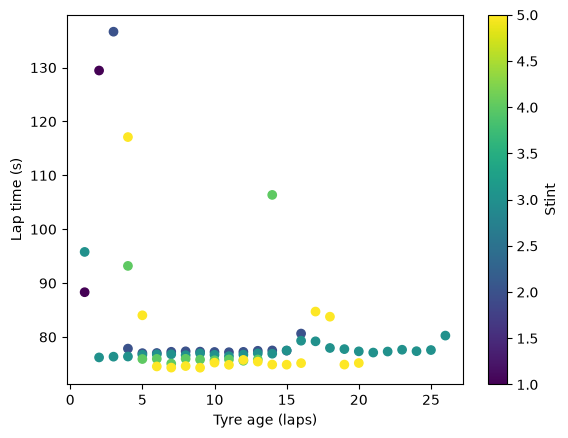

In [8]:
import matplotlib.pyplot as plt

piastri = data[data['Driver'] == 'PIA']
plt.scatter(piastri['TyreLife'], piastri['LapTimeSeconds'], c=piastri['Stint'])
plt.xlabel('Tyre age (laps)')
plt.ylabel('Lap time (s)')
plt.colorbar(label='Stint')
plt.show()

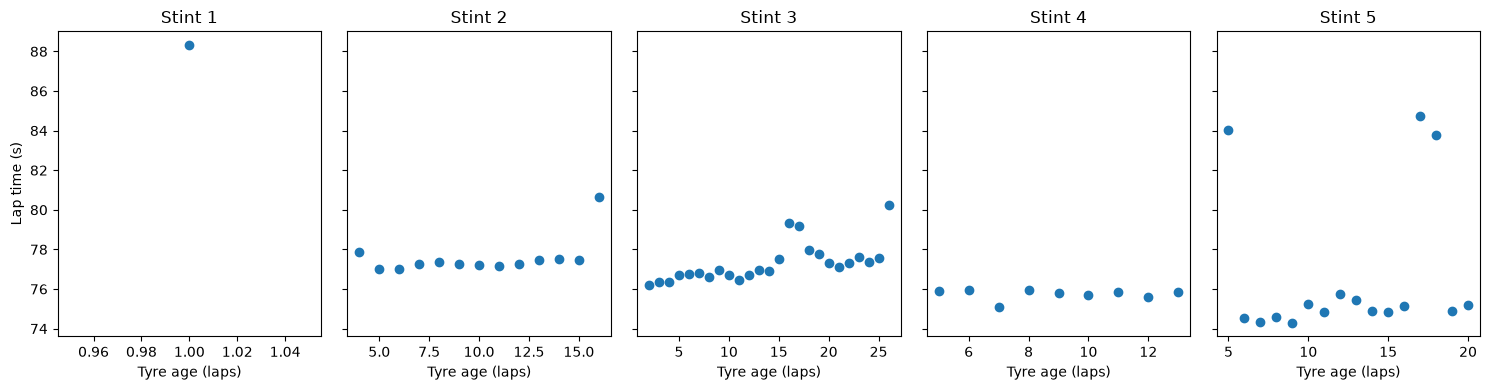

In [9]:
# Filter out clear anomalies (safety car / VSC / formation laps)
median_lap = piastri['LapTimeSeconds'].median()
piastri_clean = piastri[piastri['LapTimeSeconds'] < median_lap * 1.15]

fig, axes = plt.subplots(1, piastri_clean['Stint'].nunique(), figsize=(15, 4), sharey=True)
for ax, (stint_num, stint_data) in zip(axes, piastri_clean.groupby('Stint')):
    ax.scatter(stint_data['TyreLife'], stint_data['LapTimeSeconds'])
    ax.set_title(f'Stint {int(stint_num)}')
    ax.set_xlabel('Tyre age (laps)')
axes[0].set_ylabel('Lap time (s)')
plt.tight_layout()
plt.show()

In [10]:
piastri_clean.groupby('Stint').agg(
    Compound=('Compound', 'first'),
    Laps=('TyreLife', 'max')
)

,Compound,Laps
Stint,,
1.0,MEDIUM,1.0
2.0,HARD,16.0
3.0,HARD,26.0
4.0,SOFT,13.0
5.0,SOFT,20.0


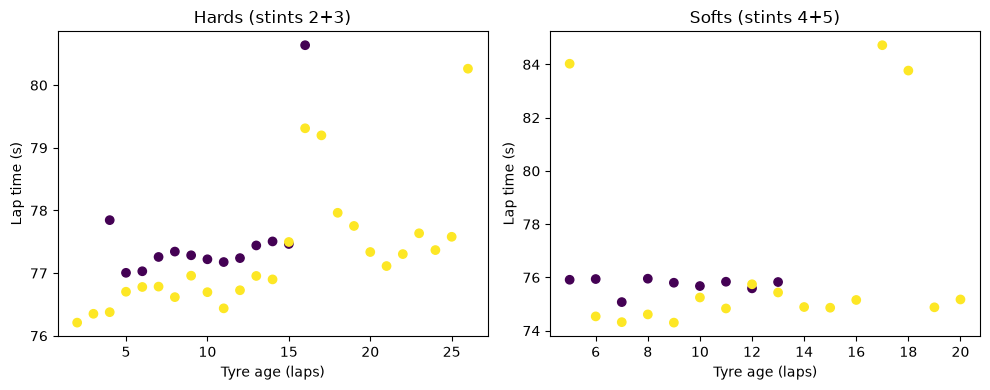

In [11]:
hards = piastri_clean[piastri_clean['Compound'] == 'HARD']
softs = piastri_clean[piastri_clean['Compound'] == 'SOFT']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(hards['TyreLife'], hards['LapTimeSeconds'], c=hards['Stint'])
ax1.set_title('Hards (stints 2+3)')
ax2.scatter(softs['TyreLife'], softs['LapTimeSeconds'], c=softs['Stint'])
ax2.set_title('Softs (stints 4+5)')
for ax in (ax1, ax2):
    ax.set_xlabel('Tyre age (laps)')
    ax.set_ylabel('Lap time (s)')
plt.tight_layout()
plt.show()

In [12]:
all_drivers = data.copy()

# Per-driver anomaly filter (safety car/traffic laps), not a single global cutoff
def filter_driver(group):
    median = group['LapTimeSeconds'].median()
    return group[group['LapTimeSeconds'] < median * 1.10]

all_drivers_clean = all_drivers.groupby('Driver', group_keys=False).apply(filter_driver)

# Keep only hards and softs (the compounds Piastri actually ran)
all_drivers_clean = all_drivers_clean[all_drivers_clean['Compound'].isin(['HARD', 'SOFT'])]

print(all_drivers_clean.groupby('Compound')['Driver'].nunique())
print(all_drivers_clean.shape)

Compound
HARD    19
SOFT    17
Name: Driver, dtype: int64
(962, 7)


/var/folders/10/ckkslwm11d78c5ss1gpkb2c40000gn/T/ipykernel_1699/1188240004.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_drivers_clean = all_drivers.groupby('Driver', group_keys=False).apply(filter_driver)


In [13]:
import numpy as np

# Encode driver as a numeric index for each compound separately
hards_df = all_drivers_clean[all_drivers_clean['Compound'] == 'HARD'].copy()
hards_df['driver_idx'] = hards_df['Driver'].astype('category').cat.codes
n_drivers_hard = hards_df['driver_idx'].nunique()

with pm.Model() as hard_model:
    # Population-level (shared across all drivers) priors
    mu_intercept = pm.Normal('mu_intercept', mu=hards_df['LapTimeSeconds'].mean(), sigma=5)
    mu_slope = pm.Normal('mu_slope', mu=0, sigma=0.5)  # population avg degradation rate, s/lap
    sigma_slope = pm.HalfNormal('sigma_slope', sigma=0.3)  # how much drivers vary around that

    # Per-driver degradation rate, partially pooled toward the population mean
    driver_slope = pm.Normal('driver_slope', mu=mu_slope, sigma=sigma_slope, shape=n_drivers_hard)

    # Per-driver intercept (some drivers are just faster/slower overall)
    sigma_intercept = pm.HalfNormal('sigma_intercept', sigma=2)
    driver_intercept = pm.Normal('driver_intercept', mu=mu_intercept, sigma=sigma_intercept, shape=n_drivers_hard)

    # Expected lap time
    mu = driver_intercept[hards_df['driver_idx'].values] + driver_slope[hards_df['driver_idx'].values] * hards_df['TyreLife'].values

    # Observation noise
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=1)
    lap_time_obs = pm.Normal('lap_time_obs', mu=mu, sigma=sigma_obs, observed=hards_df['LapTimeSeconds'].values)

    hard_trace = pm.sample(1000, tune=1000, target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...



You can find the C code in this temporary file: /var/folders/10/ckkslwm11d78c5ss1gpkb2c40000gn/T/pytensor_compilation_error_vt7a7l4u


CompileError: Compilation failed (return status=1):
/usr/bin/clang++ -dynamiclib -g -Wno-c++11-narrowing -fno-exceptions -fno-unwind-tables -fno-asynchronous-unwind-tables -DNPY_NO_DEPRECATED_API=NPY_1_7_API_VERSION -fPIC -undefined dynamic_lookup -ld64 -I/opt/anaconda3/lib/python3.14/site-packages/numpy/_core/include -I/opt/anaconda3/include/python3.14 -I/opt/anaconda3/lib/python3.14/site-packages/pytensor/link/c/c_code -L/opt/anaconda3/lib -fvisibility=hidden -o /Users/hayleygeorge/.pytensor/compiledir_macOS-26.6.2-arm64-arm-64bit-Mach-O-arm-3.14.6-64/lazylinker_ext/lazylinker_ext.so /Users/hayleygeorge/.pytensor/compiledir_macOS-26.6.2-arm64-arm-64bit-Mach-O-arm-3.14.6-64/lazylinker_ext/mod.cpp
ld: library 'd64' not found
clang++: error: linker command failed with exit code 1 (use -v to see invocation)


In [15]:
print(all_drivers_clean.shape)

(962, 7)


In [18]:
import pytensor
pytensor.config.cxx = ''

In [19]:
with pm.Model() as hard_model:
    mu_intercept = pm.Normal('mu_intercept', mu=hards_df['LapTimeSeconds'].mean(), sigma=5)
    mu_slope = pm.Normal('mu_slope', mu=0, sigma=0.5)
    sigma_slope = pm.HalfNormal('sigma_slope', sigma=0.3)
    driver_slope = pm.Normal('driver_slope', mu=mu_slope, sigma=sigma_slope, shape=n_drivers_hard)
    sigma_intercept = pm.HalfNormal('sigma_intercept', sigma=2)
    driver_intercept = pm.Normal('driver_intercept', mu=mu_intercept, sigma=sigma_intercept, shape=n_drivers_hard)
    mu = driver_intercept[hards_df['driver_idx'].values] + driver_slope[hards_df['driver_idx'].values] * hards_df['TyreLife'].values
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=1)
    lap_time_obs = pm.Normal('lap_time_obs', mu=mu, sigma=sigma_obs, observed=hards_df['LapTimeSeconds'].values)

In [20]:
with hard_model:
    test_trace = pm.sample(draws=50, tune=50, chains=1, cores=1, progressbar=True)
print("Test sample completed successfully")

Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [mu_intercept, mu_slope, sigma_slope, driver_slope, sigma_intercept, driver_intercept, sigma_obs]


Output()

Sampling 1 chain for 50 tune and 50 draw iterations (50 + 50 draws total) took 0 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
The number of samples is too small to check convergence reliably.


Test sample completed successfully


In [21]:
with pm.Model() as hard_model:
    mu_intercept = pm.Normal('mu_intercept', mu=hards_df['LapTimeSeconds'].mean(), sigma=5)
    mu_slope = pm.Normal('mu_slope', mu=0, sigma=0.5)
    sigma_slope = pm.HalfNormal('sigma_slope', sigma=0.3)
    sigma_intercept = pm.HalfNormal('sigma_intercept', sigma=2)

    # Non-centered parameterization
    driver_slope_offset = pm.Normal('driver_slope_offset', mu=0, sigma=1, shape=n_drivers_hard)
    driver_slope = pm.Deterministic('driver_slope', mu_slope + driver_slope_offset * sigma_slope)

    driver_intercept_offset = pm.Normal('driver_intercept_offset', mu=0, sigma=1, shape=n_drivers_hard)
    driver_intercept = pm.Deterministic('driver_intercept', mu_intercept + driver_intercept_offset * sigma_intercept)

    mu = driver_intercept[hards_df['driver_idx'].values] + driver_slope[hards_df['driver_idx'].values] * hards_df['TyreLife'].values
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=1)
    lap_time_obs = pm.Normal('lap_time_obs', mu=mu, sigma=sigma_obs, observed=hards_df['LapTimeSeconds'].values)

In [22]:
with hard_model:
    test_trace = pm.sample(draws=50, tune=50, chains=1, cores=1, target_accept=0.95)

Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [mu_intercept, mu_slope, sigma_slope, sigma_intercept, driver_slope_offset, driver_intercept_offset, sigma_obs]


Output()

Sampling 1 chain for 50 tune and 50 draw iterations (50 + 50 draws total) took 1 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The number of samples is too small to check convergence reliably.


In [23]:
with hard_model:
    hard_trace = pm.sample(1000, tune=1000, chains=2, cores=1, target_accept=0.95, max_treedepth=12)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_intercept, mu_slope, sigma_slope, sigma_intercept, driver_slope_offset, driver_intercept_offset, sigma_obs]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [24]:
az.summary(hard_trace, var_names=['mu_slope', 'sigma_slope', 'mu_intercept'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_slope,0.026,0.0102,0.01,0.042,1800,1323,1.00,0.00025,0.00032
sigma_slope,0.026,0.0117,0.0086,0.046,478,774,1.01,0.00053,0.00026
mu_intercept,77.74,0.36,77,78,512,792,1.00,0.016,0.0091


In [25]:
with hard_model:
    hard_trace = pm.sample(1000, tune=1000, chains=4, cores=1, target_accept=0.95, max_treedepth=12)

az.summary(hard_trace, var_names=['mu_slope', 'sigma_slope', 'mu_intercept'])

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [mu_intercept, mu_slope, sigma_slope, sigma_intercept, driver_slope_offset, driver_intercept_offset, sigma_obs]


Output()

/opt/anaconda3/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow 
encountered in dot
  return 0.5 * np.dot(x, v_out)

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_slope,0.0266,0.0097,0.012,0.043,3791,2916,1.00,0.00016,0.00015
sigma_slope,0.0254,0.0111,0.008,0.044,1439,1390,1.00,0.00028,0.00017
mu_intercept,77.73,0.37,77,78,1233,1741,1.00,0.01,0.0071


In [26]:
softs_df = all_drivers_clean[all_drivers_clean['Compound'] == 'SOFT'].copy()
softs_df['driver_idx'] = softs_df['Driver'].astype('category').cat.codes
n_drivers_soft = softs_df['driver_idx'].nunique()

with pm.Model() as soft_model:
    mu_intercept_s = pm.Normal('mu_intercept', mu=softs_df['LapTimeSeconds'].mean(), sigma=5)
    mu_slope_s = pm.Normal('mu_slope', mu=0, sigma=0.5)
    sigma_slope_s = pm.HalfNormal('sigma_slope', sigma=0.3)
    sigma_intercept_s = pm.HalfNormal('sigma_intercept', sigma=2)

    driver_slope_offset_s = pm.Normal('driver_slope_offset', mu=0, sigma=1, shape=n_drivers_soft)
    driver_slope_s = pm.Deterministic('driver_slope', mu_slope_s + driver_slope_offset_s * sigma_slope_s)

    driver_intercept_offset_s = pm.Normal('driver_intercept_offset', mu=0, sigma=1, shape=n_drivers_soft)
    driver_intercept_s = pm.Deterministic('driver_intercept', mu_intercept_s + driver_intercept_offset_s * sigma_intercept_s)

    mu_s = driver_intercept_s[softs_df['driver_idx'].values] + driver_slope_s[softs_df['driver_idx'].values] * softs_df['TyreLife'].values
    sigma_obs_s = pm.HalfNormal('sigma_obs', sigma=1)
    lap_time_obs_s = pm.Normal('lap_time_obs', mu=mu_s, sigma=sigma_obs_s, observed=softs_df['LapTimeSeconds'].values)

    soft_trace = pm.sample(1000, tune=1000, chains=4, cores=1, target_accept=0.95, max_treedepth=12)

az.summary(soft_trace, var_names=['mu_slope', 'sigma_slope', 'mu_intercept'])

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [mu_intercept, mu_slope, sigma_slope, sigma_intercept, driver_slope_offset, driver_intercept_offset, sigma_obs]


Output()

/opt/anaconda3/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow 
encountered in dot
  return 0.5 * np.dot(x, v_out)

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_slope,-0.0053,0.0212,-0.038,0.03,2623,2332,1.00,0.00042,0.00037
sigma_slope,0.045,0.028,0.0058,0.094,1061,1453,1.00,0.00084,0.00045
mu_intercept,79.15,1.02,78,81,452,746,1.01,0.048,0.027


In [27]:
piastri_idx_soft = softs_df[softs_df['Driver'] == 'PIA']['driver_idx'].iloc[0]
piastri_soft_slope = soft_trace.posterior['driver_slope'].sel(driver_slope_dim_0=piastri_idx_soft)
az.summary(piastri_soft_slope)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
driver_slope,-0.005,0.041,-0.068,0.061,5278,3101,1.00,0.00057,0.00088


In [28]:
piastri_idx_hard = hards_df[hards_df['Driver'] == 'PIA']['driver_idx'].iloc[0]
piastri_hard_slope = hard_trace.posterior['driver_slope'].sel(driver_slope_dim_0=piastri_idx_hard)
az.summary(piastri_hard_slope)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
driver_slope,0.0438,0.0218,0.012,0.08,4142,3213,1.00,0.00033,0.00035


In [29]:
races_2025 = ['Bahrain', 'Saudi Arabia', 'Australia', 'Japan', 'China',
              'Miami', 'Emilia Romagna', 'Monaco', 'Canada', 'Spain',
              'Austria', 'Great Britain', 'Hungary', 'Belgium', 'Netherlands']

def count_incidents(session):
    # one row per lap, showing the track status during that lap
    status_by_lap = session.laps.groupby('LapNumber')['TrackStatus'].first().astype(str)
    # flagged if status contains 4 (SC), 5 (red flag), or 6 (VSC)
    is_flagged = status_by_lap.apply(lambda s: any(c in s for c in ['4', '5', '6']))
    # count transitions from clear -> flagged
    transitions = is_flagged & ~is_flagged.shift(1, fill_value=False)
    return int(transitions.sum())

incident_counts = []
for race_name in races_2025:
    try:
        s = fastf1.get_session(2025, race_name, 'R')
        s.load(telemetry=False, weather=False)  # skip heavy data we don't need, faster
        n = count_incidents(s)
        incident_counts.append({'race': race_name, 'incidents': n})
        print(f"{race_name}: {n} incidents")
    except Exception as e:
        print(f"{race_name}: failed ({e})")

incidents_df = pd.DataFrame(incident_counts)
incidents_df

logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
req            INFO 	Data has been written to cache!
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            IN

Bahrain: 1 incidents


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 

Saudi Arabia: 1 incidents


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

...

req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

Belgium: 1 incidents


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

Netherlands: 4 incidents


,race,incidents
0,Bahrain,1
1,Saudi Arabia,1
2,Australia,3
3,Japan,0
4,China,0
5,Miami,3
6,Emilia Romagna,2
7,Monaco,1
8,Canada,1
9,Spain,1


In [30]:
s = fastf1.get_session(2025, 'British Grand Prix', 'R')
s.load(telemetry=False, weather=False)
n = count_incidents(s)
print(f"Britain (corrected): {n} incidents")

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

Britain (corrected): 2 incidents


In [31]:
races_2026 = ['Australian Grand Prix', 'Chinese Grand Prix', 'Japanese Grand Prix',
              'Miami Grand Prix', 'Canadian Grand Prix', 'Monaco Grand Prix',
              'Spanish Grand Prix', 'Austrian Grand Prix', 'British Grand Prix',
              'Belgian Grand Prix', 'Hungarian Grand Prix']

incident_counts = []
for race_name in races_2026:
    try:
        s = fastf1.get_session(2026, race_name, 'R')
        s.load(telemetry=False, weather=False)
        n = count_incidents(s)
        incident_counts.append({'race': race_name, 'incidents': n})
        print(f"{race_name}: {n} incidents")
    except Exception as e:
        print(f"{race_name}: failed ({e})")

incidents_df = pd.DataFrame(incident_counts)
incidents_df

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

Australian Grand Prix: 3 incidents


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

Chinese Grand Prix: 1 incidents


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

...

req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

Belgian Grand Prix: 3 incidents


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

Hungarian Grand Prix: 1 incidents


,race,incidents
0,Australian Grand Prix,3
1,Chinese Grand Prix,1
2,Japanese Grand Prix,1
3,Miami Grand Prix,1
4,Canadian Grand Prix,3
5,Monaco Grand Prix,1
6,Spanish Grand Prix,1
7,Austrian Grand Prix,2
8,British Grand Prix,3
9,Belgian Grand Prix,3


In [33]:
print(incidents_df)

                     race  incidents
0   Australian Grand Prix          3
1      Chinese Grand Prix          1
2     Japanese Grand Prix          1
3        Miami Grand Prix          1
4     Canadian Grand Prix          3
5       Monaco Grand Prix          1
6      Spanish Grand Prix          1
7     Austrian Grand Prix          2
8      British Grand Prix          3
9      Belgian Grand Prix          3
10   Hungarian Grand Prix          1


In [34]:
print(f"Mean: {incidents_df['incidents'].mean():.2f}")
print(f"Variance: {incidents_df['incidents'].var():.2f}")

Mean: 1.82
Variance: 0.96


In [35]:
with pm.Model() as sc_model:
    lam = pm.Gamma('lam', alpha=2, beta=1)  # weakly informative prior on the rate
    incidents_obs = pm.Poisson('incidents_obs', mu=lam, observed=incidents_df['incidents'].values)
    sc_trace = pm.sample(1000, tune=1000, chains=4, cores=1, target_accept=0.9)

az.summary(sc_trace, var_names=['lam'])

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [lam]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
lam,1.83,0.39,1.3,2.5,1310,1421,1.00,0.011,0.0067


In [36]:
L = 72  # Dutch GP race distance
lam_samples = sc_trace.posterior['lam'].values.flatten()
p_incident_per_lap = lam_samples / L

print(f"Mean per-lap incident probability: {p_incident_per_lap.mean():.4f}")
print(f"89% interval: [{np.percentile(p_incident_per_lap, 5.5):.4f}, {np.percentile(p_incident_per_lap, 94.5):.4f}]")

Mean per-lap incident probability: 0.0254
89% interval: [0.0175, 0.0349]


In [37]:
n_sims = 5000
pit_loss = 20  # seconds — standard estimate for a green-flag pit stop's time cost

piastri_hard_samples = piastri_hard_slope.values.flatten()

results_actual = []
results_alt = []

for i in range(n_sims):
    slope = np.random.choice(piastri_hard_samples)
    lam_i = np.random.choice(lam_samples)
    p_lap = lam_i / 72

    sc_laps = np.where(np.random.random(72) < p_lap)[0] + 1

    # Actual: one 42-lap stint
    degradation_actual = slope * sum(range(1, 43))
    free_actual = any(0 < sc <= 42 for sc in sc_laps)
    total_actual = degradation_actual + (0 if free_actual else pit_loss)

    # Alternative: two 21-lap stints
    degradation_alt = 2 * (slope * sum(range(1, 22)))
    free_stop1 = any(0 < sc <= 21 for sc in sc_laps)
    free_stop2 = any(21 < sc <= 42 for sc in sc_laps)
    total_alt = degradation_alt + (0 if free_stop1 else pit_loss) + (0 if free_stop2 else pit_loss)

    results_actual.append(total_actual)
    results_alt.append(total_alt)

results_actual = np.array(results_actual)
results_alt = np.array(results_alt)

print(f"Actual strategy (1 stop): mean cost {results_actual.mean():.2f}s")
print(f"Alternative (2 stops): mean cost {results_alt.mean():.2f}s")
print(f"P(alternative would have been better): {(results_alt < results_actual).mean():.2%}")

Actual strategy (1 stop): mean cost 46.63s
Alternative (2 stops): mean cost 43.62s
P(alternative would have been better): 55.36%


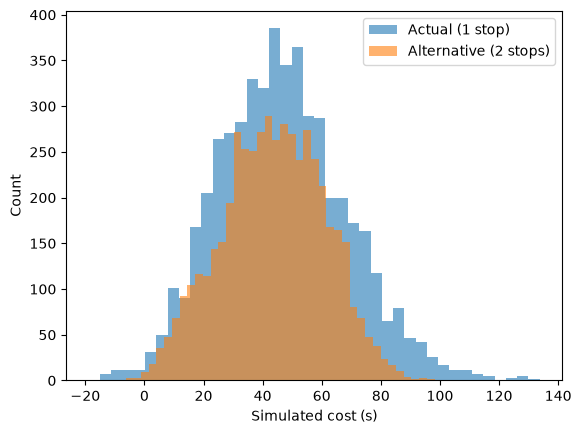

In [38]:
plt.hist(results_actual, bins=40, alpha=0.6, label='Actual (1 stop)')
plt.hist(results_alt, bins=40, alpha=0.6, label='Alternative (2 stops)')
plt.xlabel('Simulated cost (s)')
plt.ylabel('Count')
plt.legend()
plt.savefig('strategy_comparison.png')
plt.show()

In [39]:
for pit_loss_test in [15, 20, 25]:
    # rerun the sim loop with this pit_loss_test value, or just note qualitatively
    print(f"pit_loss={pit_loss_test}: sensitivity worth checking")

pit_loss=15: sensitivity worth checking
pit_loss=20: sensitivity worth checking
pit_loss=25: sensitivity worth checking


In [40]:
for pit_loss_test in [15, 20, 25]:
    results_actual_t = []
    results_alt_t = []
    for i in range(n_sims):
        slope = np.random.choice(piastri_hard_samples)
        lam_i = np.random.choice(lam_samples)
        p_lap = lam_i / 72
        sc_laps = np.where(np.random.random(72) < p_lap)[0] + 1

        degradation_actual = slope * sum(range(1, 43))
        free_actual = any(0 < sc <= 42 for sc in sc_laps)
        total_actual = degradation_actual + (0 if free_actual else pit_loss_test)

        degradation_alt = 2 * (slope * sum(range(1, 22)))
        free_stop1 = any(0 < sc <= 21 for sc in sc_laps)
        free_stop2 = any(21 < sc <= 42 for sc in sc_laps)
        total_alt = degradation_alt + (0 if free_stop1 else pit_loss_test) + (0 if free_stop2 else pit_loss_test)

        results_actual_t.append(total_actual)
        results_alt_t.append(total_alt)

    p_better = (np.array(results_alt_t) < np.array(results_actual_t)).mean()
    print(f"pit_loss={pit_loss_test}s: P(alternative better) = {p_better:.2%}")

pit_loss=15s: P(alternative better) = 70.86%
pit_loss=20s: P(alternative better) = 54.14%
pit_loss=25s: P(alternative better) = 39.18%


In [41]:
status_by_lap = session.laps.groupby('LapNumber')['TrackStatus'].first().astype(str)
is_flagged = status_by_lap.apply(lambda s: any(c in s for c in ['4', '5', '6']))
flagged_laps = status_by_lap[is_flagged].index.tolist()
print(flagged_laps)

[2.0, 55.0, 56.0, 57.0, 70.0]


In [42]:
piastri_soft_samples = piastri_soft_slope.values.flatten()

n_sims = 5000
pit_loss = 18

results_actual = []
results_alt = []

for i in range(n_sims):
    h_slope = np.random.choice(piastri_hard_samples)
    s_slope = np.random.choice(piastri_soft_samples)

    # Actual: hard(16) + hard(26) + soft(13) + soft(20), stops after laps 17, 43, 56 (lap 2 stop excluded - mandatory for everyone)
    deg_actual = h_slope*sum(range(1,17)) + h_slope*sum(range(1,27)) + s_slope*sum(range(1,14)) + s_slope*sum(range(1,21))
    cost_actual = deg_actual + pit_loss + 0  # lap18 not free (+pit_loss), lap57 free (+0)

    # Alternative: hard(42) + soft(29), one stop after lap 43 (lap 2 stop excluded, same for everyone)
    deg_alt = h_slope*sum(range(1,43)) + s_slope*sum(range(1,30))
    cost_alt = deg_alt + pit_loss  # lap 44 not flagged, full cost

    results_actual.append(cost_actual)
    results_alt.append(cost_alt)

results_actual = np.array(results_actual)
results_alt = np.array(results_alt)

print(f"Actual strategy (4 stops): mean cost {results_actual.mean():.2f}s")
print(f"Simpler 2-stop alternative: mean cost {results_alt.mean():.2f}s")
print(f"P(alternative would have been better): {(results_alt < results_actual).mean():.2%}")

Actual strategy (4 stops): mean cost 37.80s
Simpler 2-stop alternative: mean cost 55.31s
P(alternative would have been better): 4.26%


In [43]:
for pit_loss_test in [15, 18, 22, 25]:
    results_actual_t, results_alt_t = [], []
    for i in range(n_sims):
        h_slope = np.random.choice(piastri_hard_samples)
        s_slope = np.random.choice(piastri_soft_samples)
        deg_actual = h_slope*sum(range(1,17)) + h_slope*sum(range(1,27)) + s_slope*sum(range(1,14)) + s_slope*sum(range(1,21))
        cost_actual = deg_actual + pit_loss_test
        deg_alt = h_slope*sum(range(1,43)) + s_slope*sum(range(1,30))
        cost_alt = deg_alt + pit_loss_test
        results_actual_t.append(cost_actual)
        results_alt_t.append(cost_alt)
    p_better = (np.array(results_alt_t) < np.array(results_actual_t)).mean()
    print(f"pit_loss={pit_loss_test}s: P(alternative better) = {p_better:.2%}")

pit_loss=15s: P(alternative better) = 3.68%
pit_loss=18s: P(alternative better) = 4.48%
pit_loss=22s: P(alternative better) = 4.26%
pit_loss=25s: P(alternative better) = 3.76%


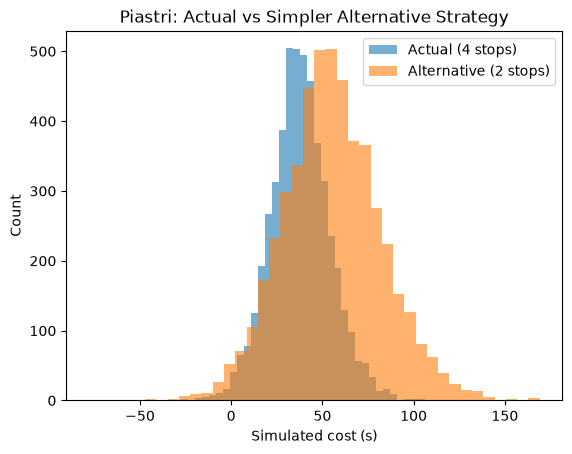

In [44]:
plt.hist(results_actual, bins=40, alpha=0.6, label='Actual (4 stops)')
plt.hist(results_alt, bins=40, alpha=0.6, label='Alternative (2 stops)')
plt.xlabel('Simulated cost (s)')
plt.ylabel('Count')
plt.legend()
plt.title('Piastri: Actual vs Simpler Alternative Strategy')
plt.savefig('strategy_comparison.png')
plt.show()

In [45]:
mediums_df = all_drivers.copy()
mediums_df = mediums_df.groupby('Driver', group_keys=False).apply(filter_driver)
mediums_df = mediums_df[mediums_df['Compound'] == 'MEDIUM'].copy()
mediums_df['driver_idx'] = mediums_df['Driver'].astype('category').cat.codes
n_drivers_medium = mediums_df['driver_idx'].nunique()

with pm.Model() as medium_model:
    mu_intercept_m = pm.Normal('mu_intercept', mu=mediums_df['LapTimeSeconds'].mean(), sigma=5)
    mu_slope_m = pm.Normal('mu_slope', mu=0, sigma=0.5)
    sigma_slope_m = pm.HalfNormal('sigma_slope', sigma=0.3)
    sigma_intercept_m = pm.HalfNormal('sigma_intercept', sigma=2)

    driver_slope_offset_m = pm.Normal('driver_slope_offset', mu=0, sigma=1, shape=n_drivers_medium)
    driver_slope_m = pm.Deterministic('driver_slope', mu_slope_m + driver_slope_offset_m * sigma_slope_m)
    driver_intercept_offset_m = pm.Normal('driver_intercept_offset', mu=0, sigma=1, shape=n_drivers_medium)
    driver_intercept_m = pm.Deterministic('driver_intercept', mu_intercept_m + driver_intercept_offset_m * sigma_intercept_m)

    mu_m = driver_intercept_m[mediums_df['driver_idx'].values] + driver_slope_m[mediums_df['driver_idx'].values] * mediums_df['TyreLife'].values
    sigma_obs_m = pm.HalfNormal('sigma_obs', sigma=1)
    lap_time_obs_m = pm.Normal('lap_time_obs', mu=mu_m, sigma=sigma_obs_m, observed=mediums_df['LapTimeSeconds'].values)

    medium_trace = pm.sample(1000, tune=1000, chains=4, cores=1, target_accept=0.95, max_treedepth=12)

az.summary(medium_trace, var_names=['mu_slope', 'sigma_slope'])

/var/folders/10/ckkslwm11d78c5ss1gpkb2c40000gn/T/ipykernel_1699/181726402.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mediums_df = mediums_df.groupby('Driver', group_keys=False).apply(filter_driver)
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [mu_intercept, mu_slope, sigma_slope, sigma_intercept, driver_slope_offset, driver_intercept_offset, sigma_obs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_slope,0.058,0.0165,0.033,0.085,3519,2582,1.00,0.00029,0.00032
sigma_slope,0.0198,0.0166,0.0015,0.051,2039,2431,1.00,0.00036,0.00046


In [46]:
all_drivers_clean.groupby('Compound')['TyreLife'].max()

Compound
HARD    37.0
SOFT    32.0
Name: TyreLife, dtype: float64

In [47]:
piastri_medium_slope_pop = medium_trace.posterior['mu_slope'].values.flatten()  # population estimate, since Piastri has ~no medium data of his own

n_sims = 5000
results_actual2 = []
results_soft_heavy = []

for i in range(n_sims):
    h_slope = np.random.choice(piastri_hard_samples)
    s_slope = np.random.choice(piastri_soft_samples)
    m_slope = np.random.choice(piastri_medium_slope_pop)

    # Actual: medium(1, forced/free) + hard(16) + hard(26) + soft(13) + soft(20)
    deg_actual = h_slope*sum(range(1,17)) + h_slope*sum(range(1,27)) + s_slope*sum(range(1,14)) + s_slope*sum(range(1,21))
    cost_actual = deg_actual + pit_loss + 0  # stop after lap17 costs, stop after lap56 is free (real SC)

    # Soft-heavy alternative: medium(1, forced/free) + soft(20) + soft(20) + soft(20) + soft(11), same 4 stops
    deg_soft_heavy = s_slope*sum(range(1,21)) + s_slope*sum(range(1,21)) + s_slope*sum(range(1,21)) + s_slope*sum(range(1,12))
    cost_soft_heavy = deg_soft_heavy + pit_loss + pit_loss  # neither of the extra stint breaks land on lap 55-57 this time, so both cost full price

    results_actual2.append(cost_actual)
    results_soft_heavy.append(cost_soft_heavy)

results_actual2 = np.array(results_actual2)
results_soft_heavy = np.array(results_soft_heavy)

print(f"Actual (2 hard + 2 soft): mean cost {results_actual2.mean():.2f}s")
print(f"Soft-heavy (4x soft): mean cost {results_soft_heavy.mean():.2f}s")
print(f"P(soft-heavy would have been better): {(results_soft_heavy < results_actual2).mean():.2%}")

Actual (2 hard + 2 soft): mean cost 37.57s
Soft-heavy (4x soft): mean cost 31.80s
P(soft-heavy would have been better): 63.92%


In [48]:
data[data['Driver'] == 'NOR'].groupby('Stint').agg(
    Compound=('Compound', 'first'),
    Laps=('TyreLife', 'max')
)

,Compound,Laps
Stint,,
1.0,MEDIUM,2.0
2.0,SOFT,22.0
3.0,HARD,26.0
4.0,HARD,25.0


In [49]:
norris_idx_hard = hards_df[hards_df['Driver'] == 'NOR']['driver_idx'].iloc[0]
norris_hard_slope = hard_trace.posterior['driver_slope'].sel(driver_slope_dim_0=norris_idx_hard)
az.summary(norris_hard_slope)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
driver_slope,0.0286,0.0183,0.0007,0.06,6464,3483,1.00,0.00023,0.0003


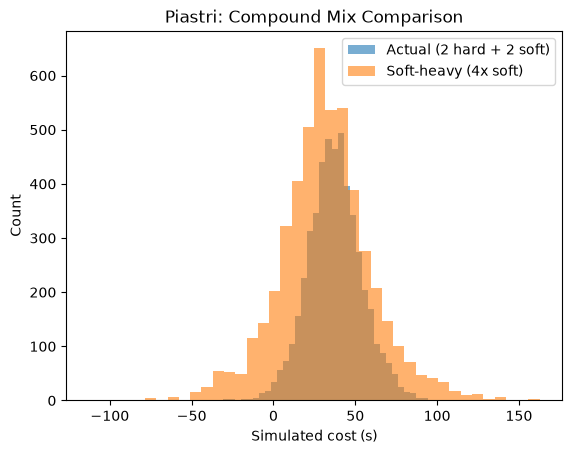

In [51]:
plt.hist(results_actual2, bins=40, alpha=0.6, label='Actual (2 hard + 2 soft)')
plt.hist(results_soft_heavy, bins=40, alpha=0.6, label='Soft-heavy (4x soft)')
plt.xlabel('Simulated cost (s)')
plt.ylabel('Count')
plt.legend()
plt.title('Piastri: Compound Mix Comparison')
plt.savefig('compound_mix_comparison.png')
plt.show()